# Image Cleaning

## Imports

In [39]:
from pathlib import Path
import pypff
from matplotlib import pyplot as plt
import numpy as np

In [40]:
# avoids crowded subplots
def colorbar(mappable, label=None):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    if label is not None:
        cbar.set_label(label)
    plt.sca(last_axes)
    return cbar

# source: https://joseph-long.com/writing/colorbars/

## Read Test Data

In [41]:
data_file = Path("../test_data/20251020/Gattini/pff/").resolve()
data_path = Path(data_file).resolve()
if not data_path.exists():
    raise FileNotFoundError(f"Data directory not found: {data_path}")
else:
    print(data_path)

/Users/nik/Documents/PANOSETI/PANOSETI-High-Energy-Analysis-Pipeline/test_data/20251020/Gattini/pff


In [42]:
# read ph1024 data file
file = str(data_path / "start_2025-10-20T06:50:55Z.dp_ph1024.bpp_2.module_254.seqno_0.pff")
pff = pypff.io.datapff(file)
data, metadata = pff.readpff(metadata=True)

## Threshold Cleaning

Let's start by plotting a "random" image (event 4321)

In [43]:
event = data[4321].reshape(32,32)

Text(0.5, 1.0, 'Raw Image')

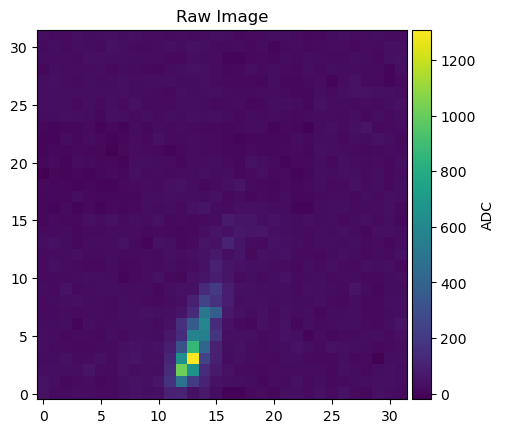

In [44]:
fig = plt.figure()
image = plt.imshow(event, aspect="equal", origin='lower')
colorbar(image, "ADC")
plt.title("Raw Image")

Now we need to import the cleaning functions

In [45]:
from heap.image_cleaning import threshold_clean

Pedvars are not implemented yet, so we will make a random distribution

In [46]:
np.random.seed(20251020)
pedvars = np.random.normal(16, 1, size=event.shape)

Text(0.5, 1.0, 'Faux Pedestal Variance Map')

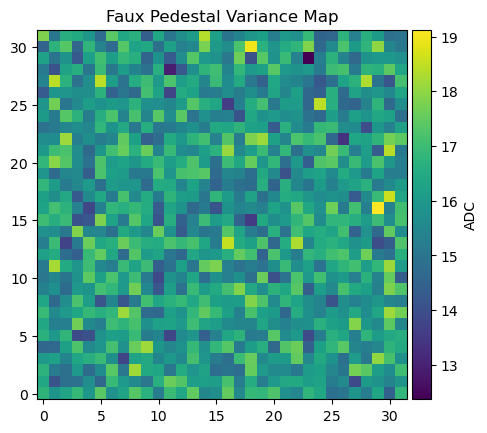

In [47]:
fig = plt.figure()
image=plt.imshow(pedvars, aspect="equal", origin='lower')
colorbar(image, "ADC")
plt.title("Faux Pedestal Variance Map")

Now let's do a simple example of image cleaning

In [48]:
cleaned_event, mask = threshold_clean(event, pedvars)

`threshold_clean()` returns the cleaned image, and a mask of the removed pixels. The mask is just a binary mapping. Here's what that looks like:

Text(0.5, 1.0, 'Removed Pixels')

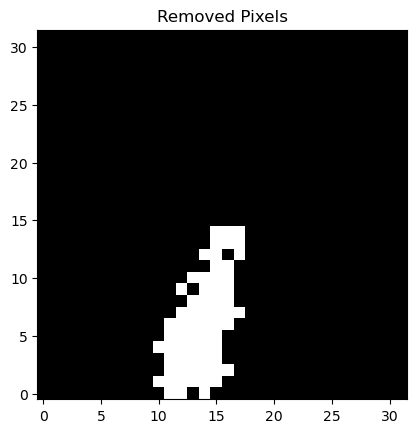

In [49]:
fig = plt.figure()
image=plt.imshow(mask, aspect="equal",cmap='binary_r', origin='lower')
plt.title("Removed Pixels")

And here is the final, cleaned image:

Text(0.5, 1.0, 'Cleaned Image')

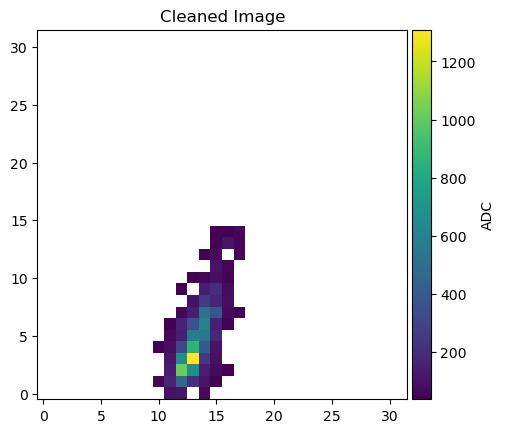

In [50]:
fig = plt.figure()
image=plt.imshow(cleaned_event, aspect="equal", origin='lower')
colorbar(image, "ADC")
plt.title("Cleaned Image")

Here's a comparison between the original image and the cleaned image:

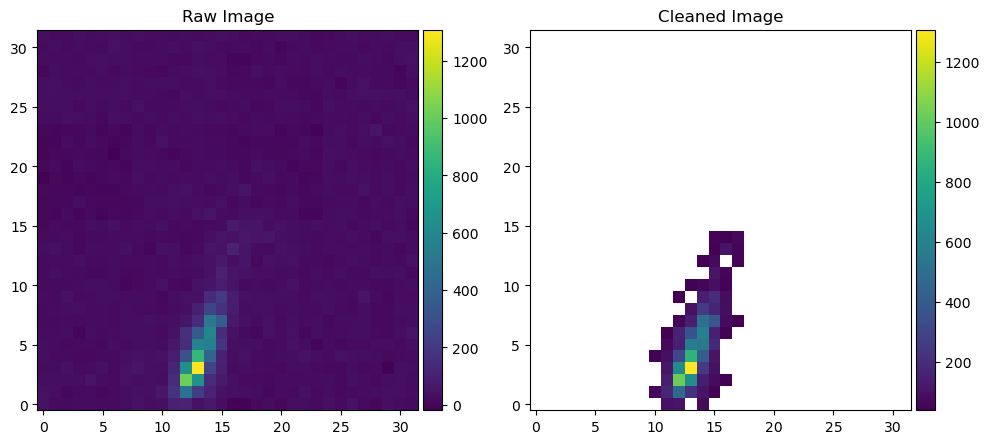

In [51]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(10,5))

# plot the raw image
image1 = ax1.imshow(event, aspect="equal", origin='lower')
colorbar(image1)
ax1.set_title("Raw Image")

# plot the cleaned image
image2 = ax2.imshow(cleaned_event, aspect="equal", origin='lower')
colorbar(image2)
ax2.set_title("Cleaned Image")

fig.tight_layout(h_pad=2)

By default, the image pixel threshold is 2.5 and the border pixel threshold is 5.0. These are in units of the pedestal variance.

We can change this in the function call of `threshold_clean()` like so:

In [52]:
cleaned_event_raised_thresh, mask_raised_thresh = threshold_clean(event, pedvars, border_threshold=3.5, image_threshold=7.0)

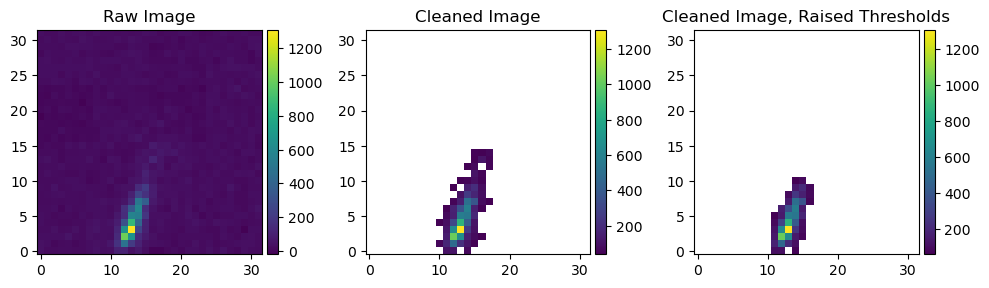

In [53]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3,figsize=(10,5))

# plot the raw image
image1 = ax1.imshow(event, aspect="equal", origin='lower')
colorbar(image1)
ax1.set_title("Raw Image")

# plot the cleaned image
image2 = ax2.imshow(cleaned_event, aspect="equal", origin='lower')
colorbar(image2)
ax2.set_title("Cleaned Image")

# plot the cleaned image with raised cleaning thresholds
image3 = ax3.imshow(cleaned_event_raised_thresh, aspect="equal", origin='lower')
colorbar(image3)
ax3.set_title("Cleaned Image, Raised Thresholds")

fig.tight_layout(h_pad=2)

Here's another example of threshold cleaning (with default thresholds) on a smaller event.

In [54]:
event2 = data[8].reshape(32,32)

In [55]:
pedvars2 = np.random.normal(16, 1, size=event2.shape)

In [56]:
cleaned_event2, mask2 = threshold_clean(event2, pedvars2)

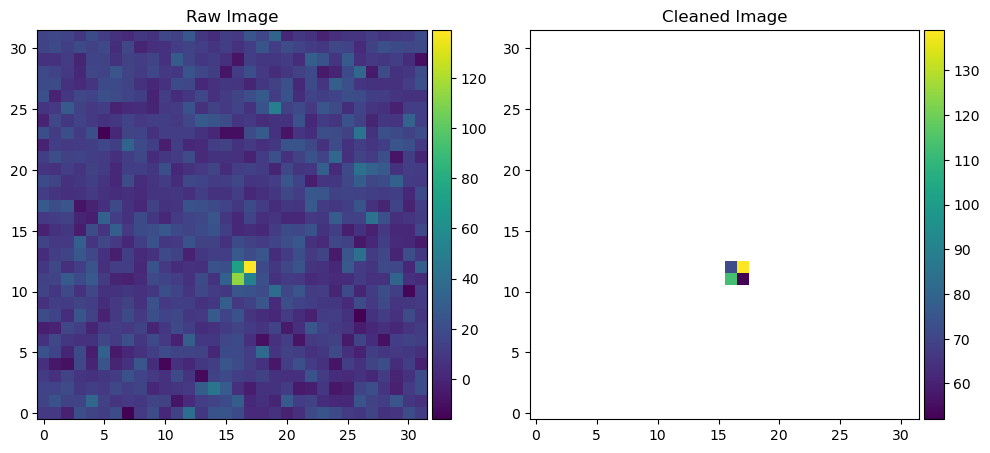

In [57]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(10,5))

# plot the raw image
image1 = ax1.imshow(event2, aspect="equal", origin='lower')
colorbar(image1)
ax1.set_title("Raw Image")

# plot the cleaned image
image2 = ax2.imshow(cleaned_event2, aspect="equal", origin='lower')
colorbar(image2)
ax2.set_title("Cleaned Image")

fig.tight_layout(h_pad=2)